In [3]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [4]:
dataframe = pd.read_excel("IMDB_final Dataset.csv.xlsx")
# Display output
print(dataframe.head())
# Display output
print(dataframe.shape)

                                              review
0  One of the other reviewers has mentioned that ...
1  A wonderful little production. <br /><br />The...
2  I thought this was a wonderful way to spend ti...
3  Basically there's a family where a little boy ...
4  Petter Mattei's "Love in the Time of Money" is...
(50000, 1)


In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word)
             for word in words
             if word not in stop_words]
    return " ".join(words)

In [6]:
df['Clean_Review'] = df['review'].apply(clean_text)
# Display output
print(df[['review','Clean_Review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        Clean_Review  
0  one reviewer mentioned watching oz episode you...  
1  wonderful little production br br filming tech...  
2  thought wonderful way spend time hot summer we...  
3  basically there family little boy jake think t...  
4  petter matteis love time money visually stunni...  


In [7]:
sia = SentimentIntensityAnalyzer()
def get_sentiment(text):
    score = sia.polarity_scores(text)
    compound = score['compound']
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'
df['Sentiment'] = df['Clean_Review'].apply(get_sentiment)
# Display output
print(dataframe.head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                        Clean_Review Sentiment  
0  one reviewer mentioned watching oz episode you...  Negative  
1  wonderful little production br br filming tech...  Positive  
2  thought wonderful way spend time hot summer we...  Positive  
3  basically there family little boy jake think t...  Negative  
4  petter matteis love time money visually stunni...  Positive  


In [8]:
counts = df['Sentiment'].value_counts()
# Display output
print(counts)

Sentiment
Positive    34108
Negative    15322
Neutral       570
Name: count, dtype: int64


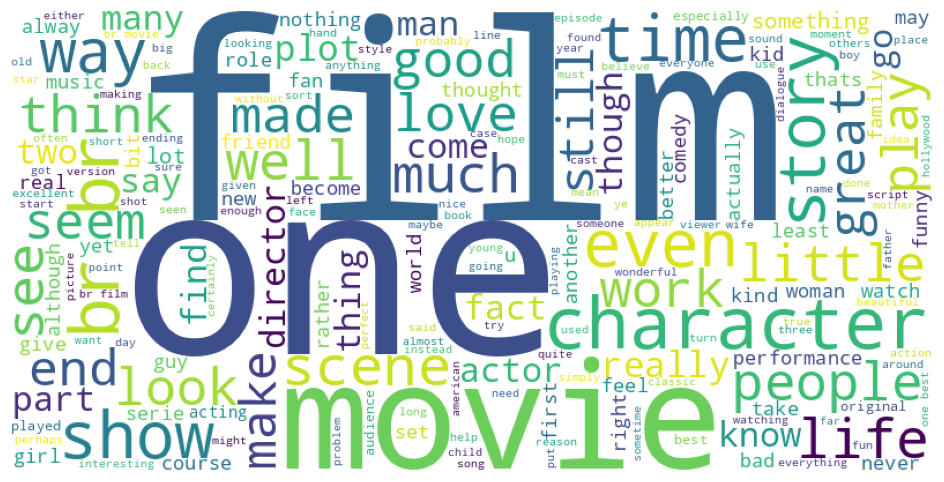

In [9]:
text = " ".join(
df[df['Sentiment']=="Positive"]
['Clean_Review']
)
wc = WordCloud(
width=800,
height=400,
background_color='white'
).generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [10]:
review = "The acting was excellent and the storyline was amazing"
review = clean_text(review)
prediction = get_sentiment(review)
# Display output
print(prediction)

Positive
